# Energy Losses Calculation

In this tutorial, we will explore one of the most important aspects of cosmic ray (CR) transport: **energy losses**. 

As CRs propagate through the interstellar medium (ISM) or within localized sources such as stellar bubbles, they interact with the surrounding gas, radiation fields and magnetic fields. These interactions lead to a continuous loss of energy, which significantly shapes the resulting CR spectra. These losses are characterized by the **loss function**, which is different for every loss mechanism.

SAETASS provides a flexible `EnergyLossCalculator` utility to compute these losses functions for different particle species in complex environments. We will now learn how to use it.

## 1. Setting up the physics environment and the plotting resources

First, we do all necessary imports and define the representative parameters of our physical environment. We will try to consider all possible energy losses mechanisms, so this includes a spatial grid, gas density profile, magnetic field and temperature profile.

In a simpler case, however, not all of these parameters might be needed.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from saetass.utils.energy_losses import EnergyLossCalculator, Particle


# Uniform ISM conditions (no spatial dependence)
r_grid = np.array([0.0]) * u.pc
n_gas = np.array([0.01]) * u.cm**-3  # Uniform gas density
T_gas = np.array([1e4]) * u.K  # Gas temperature
B_field = np.array([6.35]) * u.uG  # Magnetic field (U_B = 1 eV/cm3)
# For Inverse Compton, we define a simple CMB blackbody photon field (T = 2.725 K)
eps_grid = np.logspace(-9, -2, 120) * u.eV
T_cmb = 2.725 * u.K
prefactor = 8 * np.pi / (const.h * const.c) ** 3
exponential = np.exp(eps_grid / (const.k_B * T_cmb)) - 1
dn_deps = (prefactor * eps_grid**2 / exponential).to(u.cm**-3 * u.eV**-1)
dn_deps_2d = np.tile(dn_deps.value, (len(r_grid), 1)).T * dn_deps.unit

We will configure visual style, so as to use TeX-like fonts. This is only relevant for the graphical representation part and can be skipped.

In [26]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "legend.fontsize": 14,
        "legend.title_fontsize": 14
        ,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
    }
)

Finally, we will define a color for each loss mechanism, so that comparison between plots is easier.

In [27]:
loss_styles = {
    "ionization": {"color": "#1f77b4", "ls": "--", "label": "Ionization"},
    "pion": {"color": "#ff7f0e", "ls": "--", "label": "Pion Production"},
    "coulomb": {"color": "#2ca02c", "ls": "--", "label": "Coulomb scattering"},
    "synchrotron": {"color": "#d62728", "ls": "--", "label": "Synchrotron"},
    "bremsstrahlung": {"color": "#9467bd", "ls": "--", "label": "Bremsstrahlung"},
    "inverse_compton": {"color": "#8c564b", "ls": "--", "label": "Inverse Compton"},
    "total": {"color": "black", "ls": "-", "lw": 3, "label": "Total"}
}

## 2. Proton energy losses

For protons (and other hadrons), the main loss mechanisms are:
- **Ionization**: Interaction with atomic electrons in not fully ionized media.
- **Pion Production**: Inelastic collisions with background nuclei ($pp$ interactions).
- **Coulomb Losses**: Small-angle scattering with free electrons in a ionizied plasma.

Let's compute these for a wide energy range.

In [28]:
# Energy grid for protons
E_grid_proton = np.logspace(-3, 4, 300) * u.GeV

# Initialize the calculator
calc_p = EnergyLossCalculator(
    E_grid=E_grid_proton,
    r_grid=r_grid,
    n_gas=n_gas,
    particle=Particle("proton"),  # [*]
)
# [*] Note that particle="proton" would also work.
# However, we encourage the use of Particle() class.

# Compute mechanisms
E_dot_ion_p = calc_p.compute_ionization_losses()
E_dot_pion = calc_p.compute_pion_production_losses()
E_dot_coul_p = calc_p.compute_coulomb_losses(T_gas=T_gas)

# Compute total
E_dot_total_p = calc_p.compute_total_losses()

### Visualizing Timescales

The energy loss rate $\dot{E}$ is often represented as a characteristic timescale $\tau = E / |\dot{E}|$. This tells us how long a particle of energy $E$ would take to lose its energy.

We will look at the timescales for the different individual processes of the proton.

/Users/jmorillo/SAETASS/.venv/lib/python3.14/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


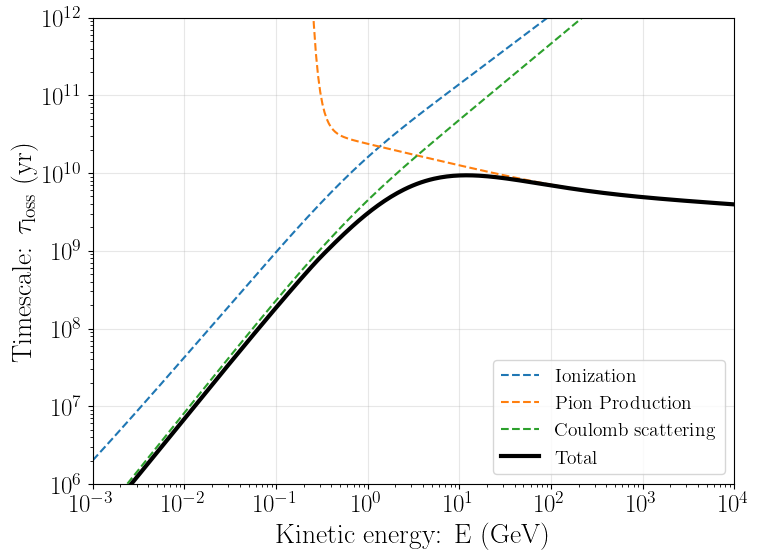

In [29]:
# Standard visualization of proton timescales
plt.figure(figsize=(8, 6))
timescales_p = calc_p.get_loss_timescales()

for mech, tau in timescales_p.items():
    style = loss_styles.get(mech, {})
    label = style.get("label", mech.capitalize())
    color = style.get("color", None)
    ls = style.get("ls", "-")
    lw = style.get("lw", 1.5)
    plt.loglog(E_grid_proton.value, tau.to("yr").value, label=label, color=color, ls=ls, lw=lw)

plt.xlabel(r"Kinetic energy: E (GeV)")
plt.ylabel(r"Timescale: $\tau_\mathrm{loss}$ (yr)")
plt.xlim(min(E_grid_proton.value), max(E_grid_proton.value))
plt.ylim(10**6,10**12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
p_fig = plt.gcf()
p_fig.savefig("proton_losses_timescales.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 3. Electron Energy Losses

Leptons (like electrons) are much lighter and lose energy much more efficiently through electromagnetic processes:
- **Ionization**: Similar to protons.
- **Synchrotron**: Radiation emitted when accelerating in a magnetic field.
- **Bremsstrahlung**: "Braking radiation" in the electric field of nuclei and electrons.
- **Inverse Compton**: Scattering of background photons to high energies.
- **Coulomb**: Interaction with ionised plasma electrons.

Let's see how these mechanisms compare for electrons. We will also compare the effect of **neutral vs ionized** gas on the Bremsstrahlung losses.

In [ ]:
# Energy grid for electrons
E_grid_electron = np.logspace(-3, 4, 300) * u.GeV

# Initialize calculator for electrons
calc_e = EnergyLossCalculator(
    E_grid=E_grid_electron,
    r_grid=r_grid,
    n_gas=n_gas,
    particle=Particle("electron")
)

# Compute mechanisms
calc_e.compute_ionization_losses()
calc_e.compute_sychrotron_losses(B_field=B_field)
calc_e.compute_coulomb_losses(T_gas=T_gas)
calc_e.compute_inverse_compton_losses(eps_grid=eps_grid, dn_deps=dn_deps_2d)

# For Bremsstrahlung, we can compare neutral and ionized gas cases
# 1. Case: Neutral gas
ionised_mask_neutral = np.zeros(len(r_grid), dtype=bool)
calc_e.compute_bremsstrahlung_losses(ionised_mask=ionised_mask_neutral)
ts_neutral = calc_e.get_loss_timescales(r_index=0)
brems_neutral = ts_neutral.get("bremsstrahlung")

# 2. Case: Fully ionized gas
ionised_mask_ionized = np.ones(len(r_grid), dtype=bool)
calc_e.compute_bremsstrahlung_losses(ionised_mask=ionised_mask_ionized)
ts_ionized = calc_e.get_loss_timescales(r_index=0)
brems_ionized = ts_ionized.get("bremsstrahlung")

# Finally, compute total losses (using the last state, e.g., ionized)
E_dot_total_e = calc_e.compute_total_losses()

Note that, as we computed Bremsstrahlung twice, the second computation has overriden the first one. This is important if we plan to use the built-in `compute_total_losses()` method.

### Visualizing Electron Timescales

Let's visualize the electron timescales, highlighting the difference between neutral and ionized Bremsstrahlung.

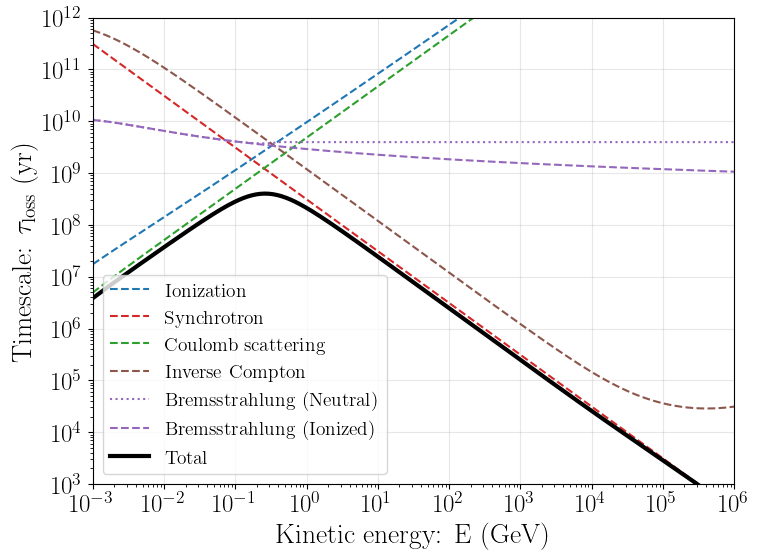

In [31]:
# Visualization of electron timescales
plt.figure(figsize=(8, 6))
timescales_e = calc_e.get_loss_timescales()

for mech, tau in timescales_e.items():
    style = loss_styles.get(mech, {})
    label = style.get("label", mech.capitalize())
    color = style.get("color", None)
    ls = style.get("ls", "-")
    lw = style.get("lw", 1.5)
    if mech == "bremsstrahlung":
        label = "Bremsstrahlung (Ionized)"
        plt.loglog(E_grid_electron.value, brems_neutral.to("yr").value, 
                   label="Bremsstrahlung (Neutral)", color=loss_styles["bremsstrahlung"]["color"], 
                   ls=":", lw=1.5)
    plt.loglog(
        E_grid_electron.value,
        tau.to("yr").value,
        label=label,
        color=color,
        ls=ls,
        lw=lw,
    )

plt.xlabel(r"Kinetic energy: E (GeV)")
plt.ylabel(r"Timescale: $\tau_\mathrm{loss}$ (yr)")
plt.xlim(min(E_grid_electron.value), max(E_grid_electron.value))
plt.ylim(10**3, 10**12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
el_fig = plt.gcf()
el_fig.savefig("electron_losses_timescales.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 4. Comparison of species

Finally, it's illustrative to compare the total cooling timescales for both protons and electrons. This highlights which species loses energy faster in the same environment.

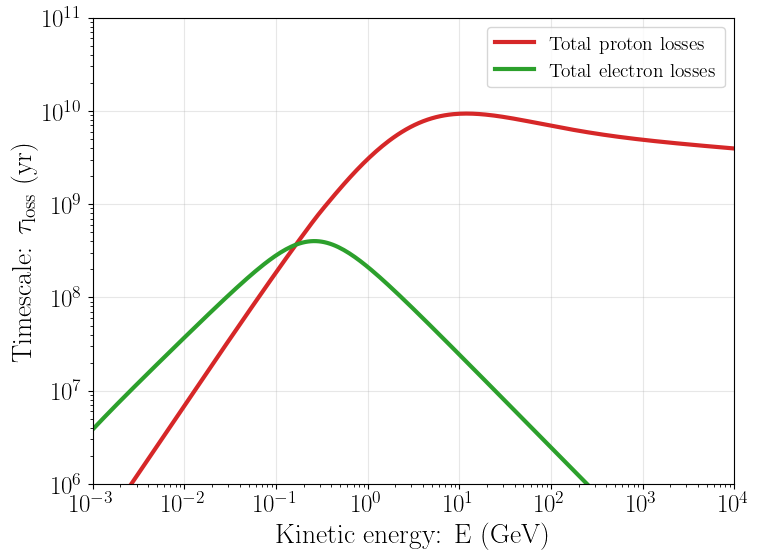

In [32]:
plt.figure(figsize=(8, 6))

# Get total timescales (index 0 for uniform grid)
tau_total_p = timescales_p['total']
tau_total_e = timescales_e['total']

plt.loglog(
    E_grid_proton.value,
    tau_total_p.to("yr").value,
    label="Total proton losses",
    lw=3,
    color="#d62728",
)
plt.loglog(
    E_grid_electron.value,
    tau_total_e.to("yr").value,
    label="Total electron losses",
    lw=3,
    color="#2ca02c",
)

plt.xlabel(r"Kinetic energy: E (GeV)")
plt.ylabel(r"Timescale: $\tau_\mathrm{loss}$ (yr)")
plt.ylim(10**6,10**11)
plt.xlim(10**-3,10**4)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Summary and Key Takeaways

In this tutorial we have seen how to:
1. Instantiate the `EnergyLossCalculator` for both protons and electrons.
2. Compute different energy loss mechanisms based on the environment characteristics.
3. Observe which processes dominate at high vs low energies.
4. Compare the overall cooling efficiency of different particle species.

These energy loss rates are essential inputs for the `Solver` when solving the transport equation, where they act as a "flow" of particles in momentum space.